In [11]:
import random
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from torch_geometric.data import Data
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('C:\\Users\\ekru\\Documents\\Cursor\\ganv2\\Project\\Dataset Creation\\Final_Graph.csv')
print(df.head())

                          Head        Relation           Tail
0       Fluocinolone acetonide  INTERACTS_WITH       Abetimus
1                   Tazarotene  INTERACTS_WITH     Oxybutynin
2                    Guanoclor  INTERACTS_WITH  Nortriptyline
3  Dexamethasone isonicotinate  INTERACTS_WITH    Oxaliplatin
4                 Sparfloxacin  INTERACTS_WITH   Iron sucrose


In [4]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [5]:
print("Train:")
print(train_df)
print("Test:")
print(test_df)
print("Validation:")
print(valid_df)

Train:
                                                   Head         Relation  \
194639                                      Venlafaxine   INTERACTS_WITH   
338072                               Dexmethylphenidate       IN_PRODUCT   
413921                                    Nortriptyline   INTERACTS_WITH   
276174                                      Prenylamine   INTERACTS_WITH   
439150                                   Isosulfan blue   INTERACTS_WITH   
...                                                 ...              ...   
259178                                          Demadex  MANUFACTURED_BY   
365838                                         Restoril        HAS_PRICE   
131932  Discount Drug Mart nausea control Cherry Flavor  MANUFACTURED_BY   
146867                                          AVE9633   INTERACTS_WITH   
121958                                         Doxapram   INTERACTS_WITH   

                                     Tail  
194639                  Magnesium su

In [6]:
#Preprocessing the data

# Strip whitespace from column names and values
for df in [train_df, test_df, valid_df]:
    df.columns = df.columns.str.strip()
    df['Head'] = df['Head'].str.strip()
    df['Tail'] = df['Tail'].str.strip()
    df['Relation'] = df['Relation'].str.strip()

# Map entities and relations to indices
entities = pd.concat([train_df['Head'], train_df['Tail'],
                      test_df['Head'], test_df['Tail'],
                      valid_df['Head'], valid_df['Tail']]).unique()
relations = pd.concat([train_df['Relation'],
                       test_df['Relation'],
                       valid_df['Relation']]).unique()

entity_to_idx = {entity: idx for idx, entity in enumerate(entities)}
relation_to_idx = {relation: idx for idx, relation in enumerate(relations)}

# Function to convert a dataframe to a torch_geometric Data object
def create_graph_data(df):
    edge_index = torch.tensor([
        [entity_to_idx[head] for head in df['Head']],
        [entity_to_idx[tail] for tail in df['Tail']]
    ], dtype=torch.long)
    
    edge_attr = torch.tensor([relation_to_idx[rel] for rel in df['Relation']], dtype=torch.long)
    
    data = Data(edge_index=edge_index, edge_attr=edge_attr)
    data.num_nodes = len(entity_to_idx)
    return data

train_data = create_graph_data(train_df)
valid_data = create_graph_data(valid_df)
test_data  = create_graph_data(test_df)


In [7]:
#Model Creation
class GNN(MessagePassing):
    def __init__(self, num_entities, num_relations, hidden_dim, num_layers=2, dropout=0.3):
        super(GNN, self).__init__(aggr='mean')
        
        self.entity_embedding = torch.nn.Embedding(num_entities, hidden_dim)
        
        self.gnn_layers = torch.nn.ModuleList()
        for _ in range(num_layers):
            self.gnn_layers.append(torch.nn.Linear(hidden_dim, hidden_dim))
        
        self.dropout = torch.nn.Dropout(dropout)
        
        self.fc = torch.nn.Linear(hidden_dim * 2, num_relations)

    def forward(self, data):
        device = data.edge_index.device
        x = self.entity_embedding(torch.arange(data.num_nodes, device=device))

        for gnn_layer in self.gnn_layers:
            x = F.relu(gnn_layer(x))
            x = self.dropout(x)
        
        x = self.propagate(data.edge_index, x=x)
        
        head_embeddings = x[data.edge_index[0]] 
        tail_embeddings = x[data.edge_index[1]] 
        
        edge_features = torch.cat([head_embeddings, tail_embeddings], dim=1)
        
        out = self.fc(edge_features)
        return F.log_softmax(out, dim=1)
    
    def message(self, x_j):
        return x_j

    def update(self, aggr_out):
        return aggr_out

In [9]:
#Training Configuration
hidden_dim = 128
num_layers = 2
dropout = 0.3
learning_rate = 0.001
epochs = 50
patience = 5

num_entities = len(entity_to_idx)
num_relations = len(relation_to_idx)

In [10]:
model = GNN(num_entities, num_relations, hidden_dim,
                 num_layers=num_layers, dropout=dropout)


criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

In [12]:
train_losses = []
train_accuracies = []

best_val_loss = float('inf')
patience_counter = 0

In [14]:
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    output = model(train_data)
    loss = criterion(output, train_data.edge_attr)
    loss.backward()
    optimizer.step()
    
    # Calculate training accuracy
    train_predictions = torch.argmax(output, dim=1)
    correct_predictions = (train_predictions.cpu().numpy() == train_data.edge_attr.cpu().numpy()).sum()
    train_accuracy = correct_predictions / len(train_data.edge_attr)
    
    # Store training loss and accuracy
    train_losses.append(loss.item())
    train_accuracies.append(train_accuracy)
    
    # Evaluate on validation data
    model.eval()
    with torch.no_grad():
        val_output = model(valid_data)
        val_loss = criterion(val_output, valid_data.edge_attr)
    
    scheduler.step()
    
    print(f"Epoch {epoch+1:02d}: Train Loss = {loss.item():.4f}, Train Acc = {train_accuracy:.4f}, Val Loss = {val_loss.item():.4f}")
    
    # Early stopping based on validation loss.
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_model_state)

Epoch 01: Train Loss = 0.9713, Train Acc = 0.7631, Val Loss = 0.9242
Epoch 02: Train Loss = 0.9666, Train Acc = 0.7631, Val Loss = 0.9155
Epoch 03: Train Loss = 0.9646, Train Acc = 0.7631, Val Loss = 0.9094
Epoch 04: Train Loss = 0.9627, Train Acc = 0.7631, Val Loss = 0.9070
Epoch 05: Train Loss = 0.9623, Train Acc = 0.7631, Val Loss = 0.9051
Epoch 06: Train Loss = 0.9662, Train Acc = 0.7631, Val Loss = 0.9034
Epoch 07: Train Loss = 0.9652, Train Acc = 0.7631, Val Loss = 0.9019
Epoch 08: Train Loss = 0.9657, Train Acc = 0.7631, Val Loss = 0.9005
Epoch 09: Train Loss = 0.9653, Train Acc = 0.7631, Val Loss = 0.8992
Epoch 10: Train Loss = 0.9631, Train Acc = 0.7631, Val Loss = 0.8979
Epoch 11: Train Loss = 0.9611, Train Acc = 0.7631, Val Loss = 0.8966
Epoch 12: Train Loss = 0.9597, Train Acc = 0.7631, Val Loss = 0.8953
Epoch 13: Train Loss = 0.9582, Train Acc = 0.7631, Val Loss = 0.8941
Epoch 14: Train Loss = 0.9535, Train Acc = 0.7631, Val Loss = 0.8935
Epoch 15: Train Loss = 0.9574, Tra

<All keys matched successfully>

In [15]:
#Evaluation
model.eval()
with torch.no_grad():
    test_output = model(test_data)
    test_loss = criterion(test_output, test_data.edge_attr)
    test_predictions = torch.argmax(test_output, dim=1)

print(f"\nTest Loss: {test_loss.item():.4f}")

#MR, MRR, Hits @ 1,3,5
def calculate_metrics(output, data):
    ranks = []
    for i in range(output.shape[0]):
        true_relation = data.edge_attr[i].item()
        scores = output[i].cpu().numpy()
        sorted_indices = np.argsort(-scores)  # higher score => lower rank index
        rank = np.where(sorted_indices == true_relation)[0][0] + 1  # 1-indexed
        ranks.append(rank)
    
    ranks = np.array(ranks)
    mrr = np.mean(1.0 / ranks)
    mr = np.mean(ranks)
    hits_at_1 = np.mean(ranks <= 1)
    hits_at_3 = np.mean(ranks <= 3)
    hits_at_5 = np.mean(ranks <= 5)
    return mrr, mr, hits_at_1, hits_at_3, hits_at_5

mrr, mr, hits_at_1, hits_at_3, hits_at_5 = calculate_metrics(test_output, test_data)

print(f"MRR: {mrr:.4f}")
print(f"MR: {mr:.4f}")
print(f"Hits@1: {hits_at_1:.4f}")
print(f"Hits@3: {hits_at_3:.4f}")
print(f"Hits@5: {hits_at_5:.4f}")


Test Loss: 0.8907
MRR: 0.8384
MR: 1.6278
Hits@1: 0.7617
Hits@3: 0.8792
Hits@5: 0.9641


In [16]:

def print_top_k_predictions(output, data, k, num_samples=3):
    indices = random.sample(range(output.shape[0]), num_samples)  # Pick random samples
    for idx in indices:
        true_relation = data.edge_attr[idx].item()
        scores = output[idx].cpu().numpy()
        sorted_indices = np.argsort(-scores)  # Sort in descending order
        top_k = sorted_indices[:k]  

        print(f"\nTest Sample {idx + 1} (True Relation: {relations[true_relation]})")
        for rank, rel_idx in enumerate(top_k, start=1):
            rel_name = relations[rel_idx]
            if rel_idx == true_relation:
                print(f"{rank}. **{rel_name}**  ✅ (Correct)")
            else:
                print(f"{rank}. {rel_name}")

print("\n--- Hits@1 Predictions ---")
print_top_k_predictions(test_output, test_data, k=1, num_samples=3)

print("\n--- Hits@3 Predictions ---")
print_top_k_predictions(test_output, test_data, k=3, num_samples=3)

print("\n--- Hits@5 Predictions ---")
print_top_k_predictions(test_output, test_data, k=5, num_samples=3)


--- Hits@1 Predictions ---

Test Sample 50422 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)

Test Sample 24034 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)

Test Sample 3961 (True Relation: HAS_SIDE_EFFECT)
1. INTERACTS_WITH

--- Hits@3 Predictions ---

Test Sample 66946 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. IN_PRODUCT
3. MANUFACTURED_BY

Test Sample 38430 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. IN_PRODUCT
3. MANUFACTURED_BY

Test Sample 57785 (True Relation: HAS_SIDE_EFFECT)
1. INTERACTS_WITH
2. IN_PRODUCT
3. MANUFACTURED_BY

--- Hits@5 Predictions ---

Test Sample 62280 (True Relation: AVAILABLE_AT)
1. INTERACTS_WITH
2. MANUFACTURED_BY
3. IN_PRODUCT
4. **AVAILABLE_AT**  ✅ (Correct)
5. HAS_PRICE

Test Sample 63948 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. MANUFACTURED_BY
3. IN_PRODUCT
4. HAS_PRICE
5. AVAILABLE_AT

Test Sample 32544 (True Relation: INTER

In [17]:
# Accuracy,Precision, Recall, F1-score
correct_predictions = (test_predictions.cpu().numpy() == test_data.edge_attr.cpu().numpy()).sum()
accuracy = correct_predictions / len(test_data.edge_attr)
precision = precision_score(test_data.edge_attr.cpu().numpy(), test_predictions.cpu().numpy(), average='macro')
recall = recall_score(test_data.edge_attr.cpu().numpy(), test_predictions.cpu().numpy(), average='macro')
f1 = f1_score(test_data.edge_attr.cpu().numpy(), test_predictions.cpu().numpy(), average='macro')
print(f"Accuracy: {accuracy:.4f} ({correct_predictions}/{len(test_data.edge_attr)})")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7617 (53362/70053)
Precision: 0.1088
Recall: 0.1429
F1 Score: 0.1235


C:\Users\ekru\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
test_df.to_csv('Results\\GNN_predictions.csv', index=False)

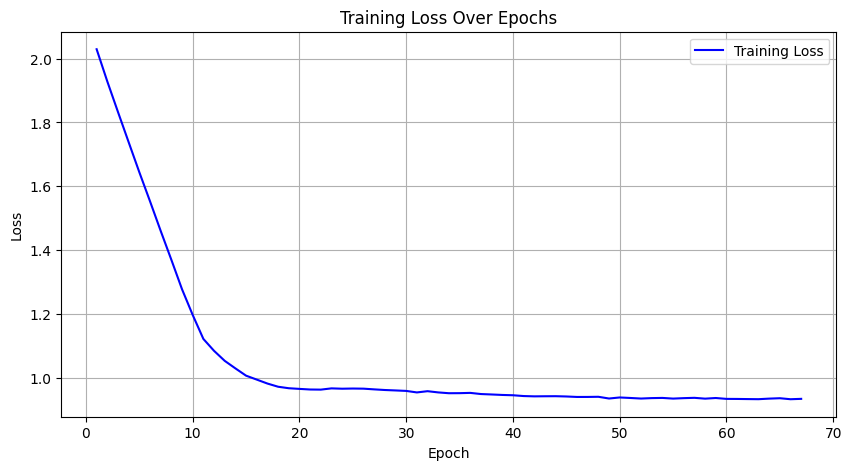

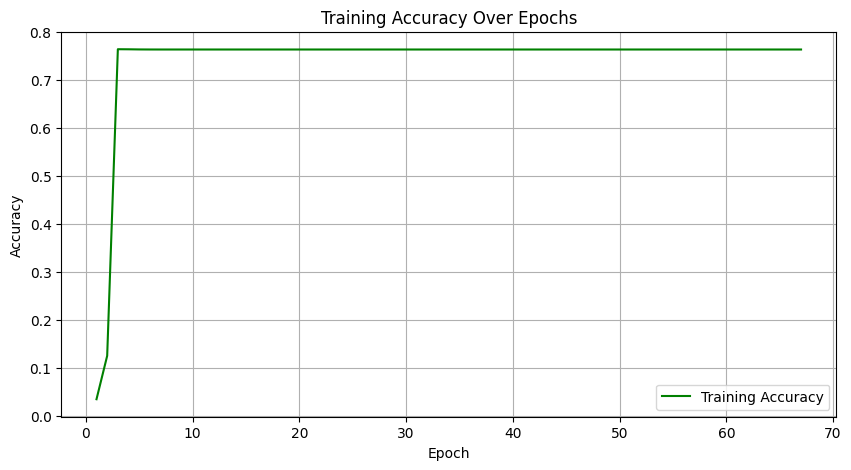

In [19]:
# Plot Training Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Training Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()